# fbm3d Example 1: Basic ISM Density Field Generation

This notebook demonstrates how to:
1. Generate a 3D ISM density field using the fbm3d_ISM class
2. Compare two different algorithms (method=1 and method=2)
3. Visualize the density distribution (3D slices and histogram)
4. Analyze the power spectrum

The ISM (Interstellar Medium) density field is generated with a lognormal distribution characterized by Mach number and magnetic field parameter.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# IMPORTANT: Edit the following PATH variable according to your installation
PATH='/Users/kiseon/GitHub/fbm3d'

import sys
sys.path.append(PATH)
from fbm_lib import *

## fbm3d_ISM: ISM Density Field Generation

**fbm3d_ISM** creates a 3D density field with:
- **Distribution**: Log-normal distribution
- **Spectrum**: Power-law-type power spectral density that mimics the interstellar medium

### Available Algorithms
- **method = 1**: Algorithm described in [Seon (2012)](https://ui.adsabs.harvard.edu/abs/2012ApJ...761L..17S/abstract)
  - Slower execution but reliable results
  
- **method = 2** (default): Implementation based on [Lewis & Austin (2002)](https://ams.confex.com/ams/11AR11CP/webprogram/Paper42772.html)
  - Faster computation with good quality results
  - Retains core ideas but differs in implementation details

### ISM Parameters
- `mach`: Mach number (typical value: 6.0) - characterizes turbulence strength
- `bvalue`: Magnetic field parameter (typical value: 0.4)
- The log-density standard deviation: `sigma_g = sqrt(ln(1 + (bvalue*mach)^2))`

In [8]:
# Grid resolution: 256^3
nx = 256
ny, nz = nx, nx

# Random seed control
seed = None                  # None: auto-generate; specify integer for reproducibility
#seed = 4070726807          # Example: uncomment to use specific seed
#seed = 2436634031

# ISM parameters
mach    = 6.0              # Mach number (turbulence strength)
bvalue  = 0.4              # Magnetic field parameter

# Calculate log-density standard deviation from ISM parameters
sigma_g = np.sqrt(np.log(1.0+(bvalue*mach)**2))
mean_g  = 0.0              # Mean of log(density) is typically 0

print(f"Grid size: {nx}x{ny}x{nz}")
print(f"Mach number: {mach}")
print(f"Magnetic field parameter: {bvalue}")
print(f"Expected log-density sigma: {sigma_g:.4f}")
print()

# Generate using method = 2 (Lewis & Austin 2002, default)
# If seed is None: random seed generated and saved as a.seed
# Log-density has mean=mean_g and standard deviation=sigma_g
print("Generating field with method=2 (Lewis & Austin 2002)...")
a = fbm3d_ISM(nx=nx,ny=ny,nz=nz,mach=mach, seed=seed, verbose=True)

# Generate using method = 1 (Seon 2012) with SAME random seed for comparison
seed = a.seed              # Reuse seed from method=2 for fair comparison
print(f"\nGenerating field with method=1 (Seon 2012) using same seed...")
p = fbm3d_ISM(nx=nx,ny=ny,nz=nz,mach=mach, method=1, seed=seed, verbose=False)

# Print results
print('\n' + '='*50)
print(f'Random seed used: {seed}')
print(f'Power spectrum slope (method=2): {a.slope_ln:.6f}')
print(f'Power spectrum slope (method=1): {p.slope_ln:.6f}')
print('='*50)

Grid size: 256x256x256
Mach number: 6.0
Magnetic field parameter: 0.4
Expected log-density sigma: 1.3824

Generating field with method=2 (Lewis & Austin 2002)...
iteration =   1 / convergence = 37.06 %
iteration =   2 / convergence = 72.54 %
iteration =   3 / convergence = 89.23 %
iteration =   4 / convergence = 96.51 %
iteration =   5 / convergence = 99.44 %
iteration =   6 / convergence = 99.52 %

Generating field with method=1 (Seon 2012) using same seed...

Random seed used: 3814960109
Power spectrum slope (method=2): 2.860361
Power spectrum slope (method=1): 2.860361


## Visualization: 3D Density Slices and Histogram

The figure shows:
- **Left 3 panels**: Three orthogonal slices (xy, xz, yz) of the 3D log-density field
  - Each slice shows spatial structure of density variations
  - Color scale represents log(rho)
- **Right panel**: Histogram of log-density values
  - Blue: actual distribution from generated field
  - Red: theoretical Gaussian (expected distribution)
  - Should align if algorithm working correctly

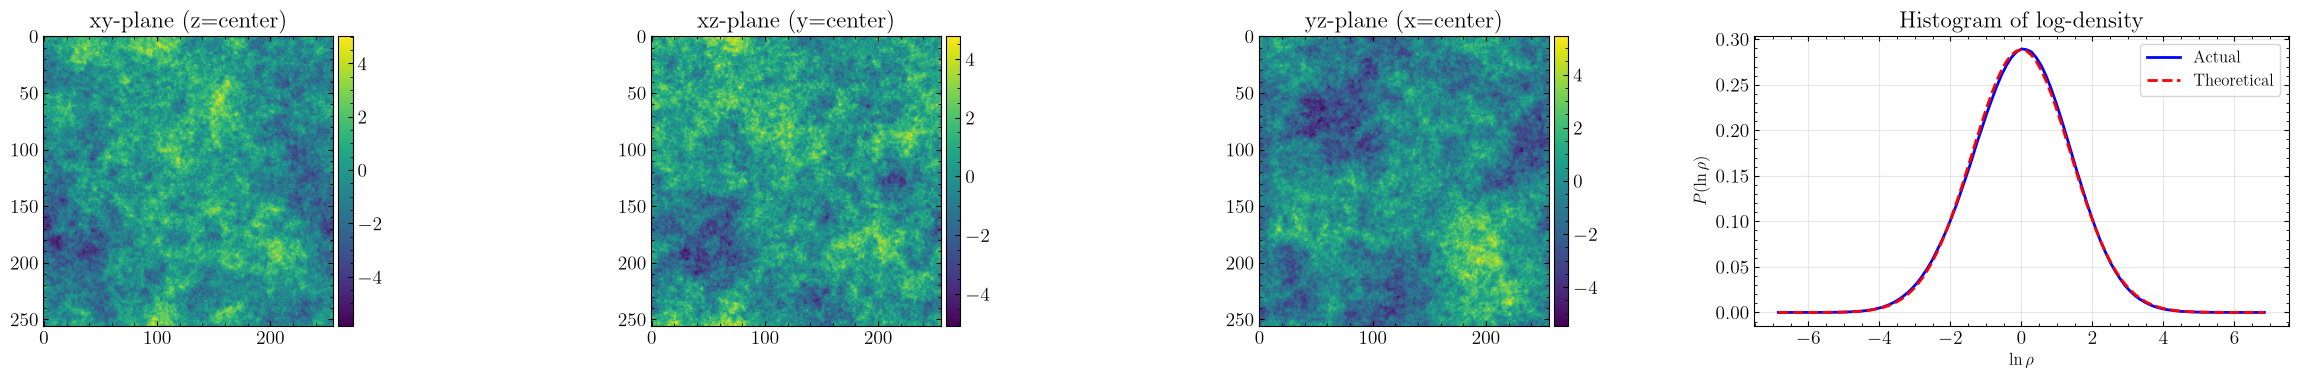

Figure saved as 'example1_method2_density.png'


In [9]:
# Plot Density Field from method = 2 (default method, Lewis & Austin 2002)

fig, ax = plt.subplots(1,4, figsize=(24,4))
ln_data = np.log(a.data)  # Convert to log scale for better visualization

# Plot three orthogonal slices through center of 3D volume
im0 = ax[0].imshow(ln_data[:,:,nz//2], cmap='viridis')      # xy-plane slice at z=nz/2
im1 = ax[1].imshow(ln_data[:,ny//2,:], cmap='viridis')      # xz-plane slice at y=ny/2
im2 = ax[2].imshow(ln_data[nx//2,:,:], cmap='viridis')      # yz-plane slice at x=nx/2

# Add colorbars to each slice
add_colorbar(im0)
add_colorbar(im1)
add_colorbar(im2)

ax[0].set_title('xy-plane (z=center)')
ax[1].set_title('xz-plane (y=center)')
ax[2].set_title('yz-plane (x=center)')

# Plot histogram of log(density) values
bins = np.linspace(-5.0*sigma_g, 5.0*sigma_g, 100) + mean_g  # Histogram bins
x    = (bins[:-1]+bins[1:])/2.0                               # Bin centers
h,_  = np.histogram(ln_data, bins, density=True)              # Normalized histogram

# Theoretical Gaussian distribution for comparison
y    = 1./np.sqrt(2.*np.pi*sigma_g**2) * np.exp(-(x-mean_g)**2/(2*sigma_g**2))

ax[3].plot(x,h, 'b-', linewidth=2, label='Actual')           # Histogram from data (blue)
ax[3].plot(x,y, 'r--', linewidth=2, label='Theoretical')     # Theoretical curve (red)
ax[3].set_xlabel(r'$\ln\rho$', fontsize=12)
ax[3].set_ylabel(r'$P(\ln\rho)$', fontsize=12)
ax[3].set_title('Histogram of log-density')
ax[3].legend()
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('example1_method2_density.png', dpi=100, bbox_inches='tight')
plt.show()

print("Figure saved as 'example1_method2_density.png'")

## Comparison: Density Field from method=1 (Seon 2012)

Compare density field generated using method=1 (Seon 2012) with method=2.
Both use same random seed for direct comparison.

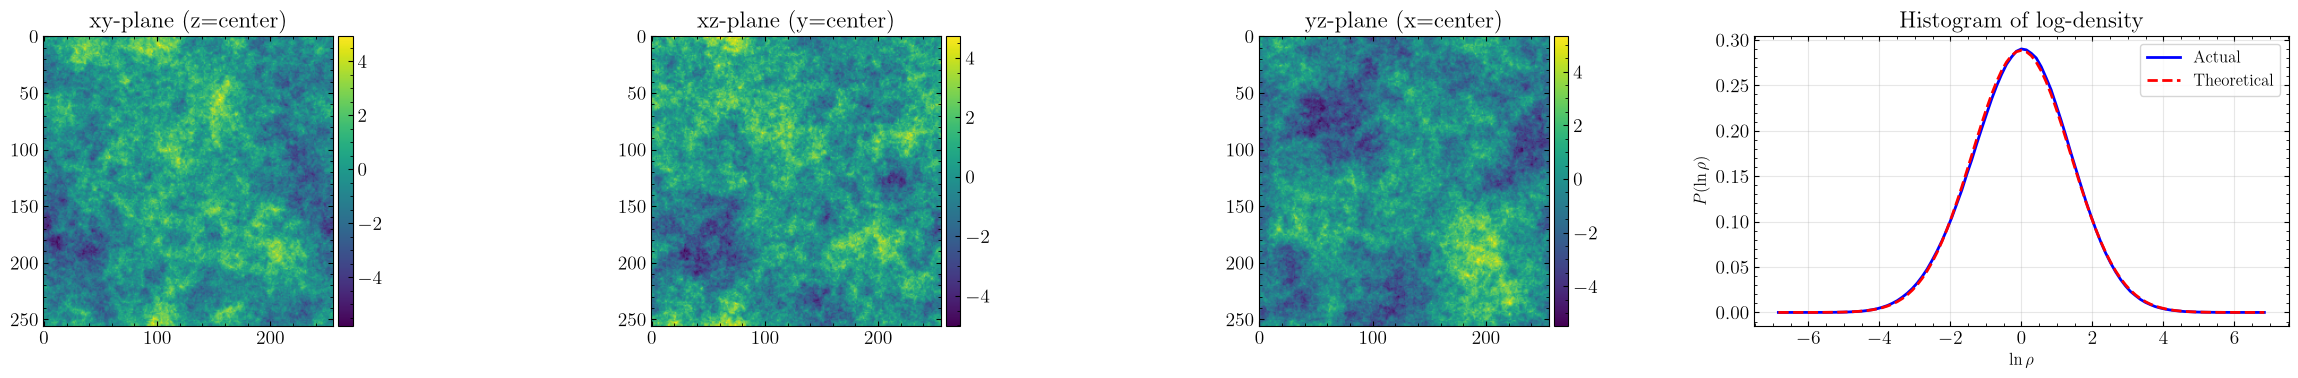

Figure saved as 'example1_method1_density.png'


In [10]:
# Plot Density Field from method = 1 (Seon 2012)

fig, ax = plt.subplots(1,4, figsize=(24,4))
ln_data = np.log(p.data)  # Convert to log scale
im0 = ax[0].imshow(ln_data[:,:,nz//2], cmap='viridis')
im1 = ax[1].imshow(ln_data[:,ny//2,:], cmap='viridis')
im2 = ax[2].imshow(ln_data[nx//2,:,:], cmap='viridis')

add_colorbar(im0)
add_colorbar(im1)
add_colorbar(im2)

ax[0].set_title('xy-plane (z=center)')
ax[1].set_title('xz-plane (y=center)')
ax[2].set_title('yz-plane (x=center)')

bins = np.linspace(-5.0*sigma_g, 5.0*sigma_g, 100) + mean_g
x    = (bins[:-1]+bins[1:])/2.0
h,_  = np.histogram(ln_data, bins, density=True)
y    = 1./np.sqrt(2.*np.pi*sigma_g**2) * np.exp(-(x-mean_g)**2/(2*sigma_g**2))
ax[3].plot(x,h, 'b-', linewidth=2, label='Actual')
ax[3].plot(x,y, 'r--', linewidth=2, label='Theoretical')
ax[3].set_xlabel(r'$\ln\rho$', fontsize=12)
ax[3].set_ylabel(r'$P(\ln\rho)$', fontsize=12)
ax[3].set_title('Histogram of log-density')
ax[3].legend()
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('example1_method1_density.png', dpi=100, bbox_inches='tight')
plt.show()

print("Figure saved as 'example1_method1_density.png'")

## Power Spectrum Analysis

Analyze the power spectrum of the generated density field.
The power spectrum should follow a power law: P(k) ∝ k^(-slope)

- **Blue dots**: Actual power spectrum from the generated field
- **Red line**: Theoretical power-law fit with computed slope
- **Log-log scale**: Makes the power-law relationship linear

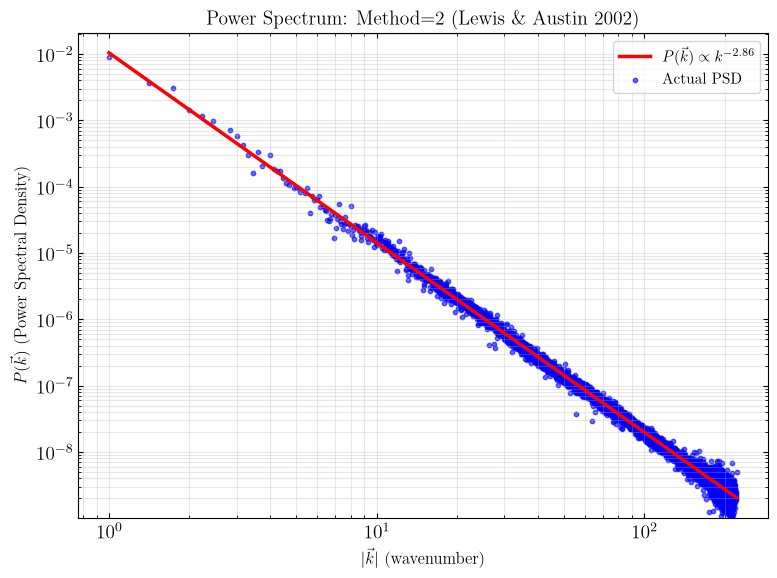

Figure saved as 'example1_power_spectrum.png'

Power spectrum exponent: 2.8604


In [11]:
# Calculate power spectrum
kr_a, PSD_a = calculate_PSD(a.data)

# Calculate normalization factor for theoretical power-law
ynorm = calculate_PSD_norm(a.data.shape, a.slope_ln)

# Theoretical power law: P(k) ∝ k^(-slope)
y = kr_a**(-a.slope_ln) * ynorm
y[0] = 0.0  # Avoid singular point at k=0

# Create plot
fig, ax = plt.subplots(1,1, figsize=(8,6))
lab = r'$P(\vec{k}) \propto k^{-%.2f}$' % (a.slope_ln)

ax.plot(kr_a[1:], y[1:], 'r-', linewidth=2.5, label=lab)     # Theoretical fit (red line)
ax.scatter(kr_a[1:], PSD_a[1:], s=10, color='blue', alpha=0.6, label='Actual PSD')  # Actual data (blue dots)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$|\vec{k}|$ (wavenumber)', fontsize=12)
ax.set_ylabel(r'$P(\vec{k})$ (Power Spectral Density)', fontsize=12)
ax.set_title('Power Spectrum: Method=2 (Lewis \& Austin 2002)', fontsize=14)
ax.set_ylim(np.amin(y[1:])*0.5, np.amax(y[1:])*2)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
#plt.savefig('example1_power_spectrum.png', dpi=100, bbox_inches='tight')
plt.show()

print("Figure saved as 'example1_power_spectrum.png'")
print(f"\nPower spectrum exponent: {a.slope_ln:.4f}")

## Summary Statistics

Compare statistical properties of both methods

In [12]:
# Compare statistics between methods
log_a = np.log(a.data)
log_p = np.log(p.data)

print("\n" + "="*60)
print("STATISTICAL COMPARISON")
print("="*60)
print(f"\nMethod=2 (Lewis & Austin 2002):")
print(f"  Mean of log(rho): {np.mean(log_a):.6f} (expected: {mean_g:.6f})")
print(f"  Std  of log(rho): {np.std(log_a):.6f} (expected: {sigma_g:.6f})")
print(f"  Min  of log(rho): {np.min(log_a):.6f}")
print(f"  Max  of log(rho): {np.max(log_a):.6f}")
print(f"  Power spectrum exponent: {a.slope_ln:.6f}")

print(f"\nMethod=1 (Seon 2012):")
print(f"  Mean of log(rho): {np.mean(log_p):.6f} (expected: {mean_g:.6f})")
print(f"  Std  of log(rho): {np.std(log_p):.6f} (expected: {sigma_g:.6f})")
print(f"  Min  of log(rho): {np.min(log_p):.6f}")
print(f"  Max  of log(rho): {np.max(log_p):.6f}")
print(f"  Power spectrum exponent: {p.slope_ln:.6f}")

print("\n" + "="*60)


STATISTICAL COMPARISON

Method=2 (Lewis & Austin 2002):
  Mean of log(rho): 0.000000 (expected: 0.000000)
  Std  of log(rho): 1.382398 (expected: 1.382398)
  Min  of log(rho): -6.844245
  Max  of log(rho): 7.674225
  Power spectrum exponent: 2.860361

Method=1 (Seon 2012):
  Mean of log(rho): -0.000000 (expected: 0.000000)
  Std  of log(rho): 1.382398 (expected: 1.382398)
  Min  of log(rho): -6.744182
  Max  of log(rho): 7.655217
  Power spectrum exponent: 2.860361

